## NDOSMS Synthetic Data Generation

This notebook demonstrates how to generate realistic synthetic SAR data for oil spill detection training.

### What this notebook does:
1. Initializes the SAR simulator with physical parameters
2. Generates various oil spill scenarios
3. Visualizes the synthetic data
4. Exports training datasets

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from data_generation.realistic_sar_simulator import RealisticSARSimulator

# Set random seed for reproducibility
np.random.seed(42)

print("Imports successful!")

IndentationError: expected an indented block after function definition on line 296 (realistic_sar_simulator.py, line 305)

### 1. Initialize Simulator

Create a simulator instance with desired image size.

In [ ]:
# Initialize simulator
simulator = RealisticSARSimulator(
    image_size=(512, 512),
    seed=42
)

print(f"Simulator initialized with image size: {simulator.size}")
print(f"Default parameters:")
print(f"  - Wavelength: {simulator.params.wavelength} m")
print(f"  - Incidence angle: {simulator.params.incidence_angle}°")
print(f"  - Wind speed: {simulator.params.wind_speed} m/s")

### 2. Generate Single Scenario

Create one oil spill scenario and visualize it.

In [ ]:
# Define spill parameters
spill_centers = [(256, 256)]  # Center of image
spill_radii = [80]  # 80 pixels radius

# Generate scenario
sar_image, ground_truth, confidence_map, metadata = simulator.generate_oil_spill_scenario(
    spill_centers=spill_centers,
    spill_radii=spill_radii,
    weather_condition="moderate",
    oil_properties={
        "spill_thickness_mm": 1.0,
        "oil_age_hours": 24
    }
)

print("Scenario generated!")
print(f"Metadata: {metadata}")

In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# SAR Image
axes[0].imshow(sar_image, cmap='gray', vmin=0, vmax=0.5)
axes[0].set_title('Synthetic SAR Image')
axes[0].axis('off')

# Ground Truth
axes[1].imshow(ground_truth, cmap='Reds')
axes[1].set_title('Ground Truth (Oil Spill)')
axes[1].axis('off')

# Confidence Map
im = axes[2].imshow(confidence_map, cmap='viridis', vmin=0, vmax=1)
axes[2].set_title('Confidence Map')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nImage Statistics:")
print(f"  SAR mean backscatter: {np.mean(sar_image):.4f}")
print(f"  Oil region mean: {np.mean(sar_image[ground_truth > 0]):.4f}")
print(f"  Water region mean: {np.mean(sar_image[ground_truth == 0]):.4f}")
print(f"  Contrast (water/oil): {np.mean(sar_image[ground_truth == 0]) / np.mean(sar_image[ground_truth > 0]):.2f}x")

### 3. Compare Weather Conditions

See how different weather affects the SAR image and oil visibility.

In [ ]:
weather_conditions = ["calm", "moderate", "rough", "storm"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, weather in enumerate(weather_conditions):
    # Generate scenario
    sar, mask, conf, meta = simulator.generate_oil_spill_scenario(
        spill_centers=[(256, 256)],
        spill_radii=[60],
        weather_condition=weather,
        oil_properties={"spill_thickness_mm": 1.0}
    )
    
    # SAR Image
    axes[0, i].imshow(sar, cmap='gray', vmin=0, vmax=0.6)
    axes[0, i].set_title(f'{weather.capitalize()}\nWind: {meta["environmental_conditions"]["wind_speed_ms"]} m/s')
    axes[0, i].axis('off')
    
    # Confidence Map
    axes[1, i].imshow(conf, cmap='viridis', vmin=0, vmax=1)
    axes[1, i].set_title(f'Confidence: {np.mean(conf):.2f}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### 4. Compare Oil Thickness

Thicker oil = stronger damping = darker in SAR.

In [ ]:
thicknesses = [0.1, 0.5, 1.0, 5.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, thick in enumerate(thicknesses):
    sar, mask, conf, meta = simulator.generate_oil_spill_scenario(
        spill_centers=[(256, 256)],
        spill_radii=[60],
        weather_condition="moderate",
        oil_properties={"spill_thickness_mm": thick}
    )
    
    axes[i].imshow(sar, cmap='gray', vmin=0, vmax=0.5)
    axes[i].set_title(f'Thickness: {thick} mm\nOil mean: {np.mean(sar[mask > 0]):.4f}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 5. Generate Training Dataset

Generate multiple scenarios and save for model training.

In [ ]:
# Cell 13: Generate Training Dataset (Workaround Version)
import sys
import os
import numpy as np
import random
import json
from datetime import datetime

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

print("=" * 60)
print("CELL 13: Generating Training Dataset")
print("=" * 60)

# Import only what we need (avoid the broken save_scenario)
from data_generation.realistic_sar_simulator import RealisticSARSimulator, SARParameters

# Monkey-patch the broken save_scenario method with a working version
def fixed_save_scenario(self, sar_image, ground_truth, confidence_map, metadata, output_dir, scenario_id):
    """Fixed version using Affine.scale instead of Affine.identity * float"""
    import rasterio
    from rasterio.transform import Affine
    
    os.makedirs(output_dir, exist_ok=True)
    
    # FIX: Use Affine.scale instead of Affine.identity * float
    pixel_size = float(self.params.resolution_m)
    transform = Affine.scale(pixel_size, pixel_size)
    
    # Save SAR image
    sar_path = os.path.join(output_dir, f"{scenario_id}_sar.tif")
    with rasterio.open(
        sar_path, 'w',
        driver='GTiff',
        height=sar_image.shape[0],
        width=sar_image.shape[1],
        count=1,
        dtype=sar_image.dtype,
        crs='EPSG:4326',
        transform=transform
    ) as dst:
        dst.write(sar_image, 1)
    
    # Save mask
    mask_path = os.path.join(output_dir, f"{scenario_id}_mask.tif")
    with rasterio.open(
        mask_path, 'w',
        driver='GTiff',
        height=ground_truth.shape[0],
        width=ground_truth.shape[1],
        count=1,
        dtype=ground_truth.dtype,
        crs='EPSG:4326',
        transform=transform
    ) as dst:
        dst.write(ground_truth, 1)
    
    # Save confidence
    conf_path = os.path.join(output_dir, f"{scenario_id}_confidence.tif")
    with rasterio.open(
        conf_path, 'w',
        driver='GTiff',
        height=confidence_map.shape[0],
        width=confidence_map.shape[1],
        count=1,
        dtype=confidence_map.dtype,
        crs='EPSG:4326',
        transform=transform
    ) as dst:
        dst.write(confidence_map, 1)
    
    # Save metadata
    meta_path = os.path.join(output_dir, f"{scenario_id}_metadata.json")
    with open(meta_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    return {
        "sar_image": sar_path,
        "ground_truth": mask_path,
        "confidence": conf_path,
        "metadata": meta_path
    }

# Apply the monkey patch
RealisticSARSimulator.save_scenario = fixed_save_scenario
print("✓ Applied fix to save_scenario method")

# Set up output directory
output_dir = "../data/synthetic_training"
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Output directory ready: {output_dir}")

# Create simulator
print("\nCreating simulator...")
simulator = RealisticSARSimulator(image_size=(512, 512), seed=42)
print(f"✓ Simulator ready (size: {simulator.size})")

# Generate dataset manually
print("\nGenerating 10 scenarios...")
generated_files = []

for i in range(10):
    # Random parameters
    n_spills = random.randint(1, 3)
    weather = random.choice(["calm", "moderate", "rough"])
    
    centers = []
    radii = []
    for _ in range(n_spills):
        cy = random.randint(128, 384)
        cx = random.randint(128, 384)
        radius = random.randint(20, 80)
        centers.append((cy, cx))
        radii.append(radius)
    
    oil_props = {
        "spill_thickness_mm": random.uniform(0.1, 5.0),
        "oil_age_hours": random.uniform(0, 72),
        "oil_viscosity": random.uniform(100, 1000)
    }
    
    # Generate scenario
    sar, mask, conf, meta = simulator.generate_oil_spill_scenario(
        spill_centers=centers,
        spill_radii=radii,
        weather_condition=weather,
        oil_properties=oil_props
    )
    
    # Save using the fixed method
    scenario_id = f"scenario_{i:05d}"
    files = simulator.save_scenario(sar, mask, conf, meta, output_dir, scenario_id)
    generated_files.append(files)
    
    if (i + 1) % 5 == 0:
        print(f"  Generated {i + 1}/10 scenarios")

print(f"\n✓ Generation complete!")
print(f"  Created {len(generated_files)} scenarios")
print(f"\nFirst scenario files:")
for key, path in generated_files[0].items():
    print(f"  {key}: {os.path.basename(path)}")

# Verify files exist
print("\nVerifying files...")
all_files = os.listdir(output_dir)
sar_files = [f for f in all_files if f.endswith('_sar.tif')]
print(f"  Total files: {len(all_files)}")
print(f"  SAR images: {len(sar_files)}")

print("\n" + "=" * 60)
print("CELL 13 COMPLETE - Ready for visualization")
print("=" * 60)

### 6. Verify Generated Dataset

Load and inspect a few samples from the generated dataset.

In [ ]:
import glob
import rasterio

# Find generated files
sar_files = sorted(glob.glob(f"{output_dir}/*_sar.tif"))[:5]

fig, axes = plt.subplots(len(sar_files), 3, figsize=(12, 4*len(sar_files)))

for i, sar_file in enumerate(sar_files):
    base = sar_file.replace("_sar.tif", "")
    
    # Load files
    with rasterio.open(sar_file) as src:
        sar = src.read(1)
    with rasterio.open(f"{base}_mask.tif") as src:
        mask = src.read(1)
    with rasterio.open(f"{base}_confidence.tif") as src:
        conf = src.read(1)
    
    # Plot
    axes[i, 0].imshow(sar, cmap='gray', vmin=0, vmax=0.5)
    axes[i, 0].set_title(f'Sample {i+1}: SAR')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask, cmap='Reds')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(conf, cmap='viridis', vmin=0, vmax=1)
    axes[i, 2].set_title(f'Confidence: {np.mean(conf):.2f}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### 7. Export for Training

Convert to numpy arrays for direct model training.

In [ ]:
import os

# Load all data into memory for training
sar_images = []
masks = []
confidences = []

for i in range(100):
    base = f"{output_dir}/scenario_{i:05d}"
    
    if os.path.exists(f"{base}_sar.tif"):
        with rasterio.open(f"{base}_sar.tif") as src:
            sar_images.append(src.read(1))
        with rasterio.open(f"{base}_mask.tif") as src:
            masks.append(src.read(1))
        with rasterio.open(f"{base}_confidence.tif") as src:
            confidences.append(src.read(1))

# Convert to numpy arrays
X = np.array(sar_images)[..., np.newaxis]  # Add channel dimension
Y = np.array(masks)
C = np.array(confidences)

print(f"Training data shape:")
print(f"  X (SAR images): {X.shape}")
print(f"  Y (masks): {Y.shape}")
print(f"  C (confidence): {C.shape}")

# Save as numpy for fast loading
np.save(f"{output_dir}/X_train.npy", X)
np.save(f"{output_dir}/Y_train.npy", Y)
np.save(f"{output_dir}/C_train.npy", C)

print(f"\nSaved numpy arrays to {output_dir}")
print("Ready for model training!")

### Next Steps

1. Use generated data to train the U-Net++ model (see `02_train_model.ipynb`)
2. Evaluate model with uncertainty quantification
3. Deploy via API for operational use

### 8. Train U-Net++ Model

Now that we have generated synthetic data, let's train the U-Net++ model.

In [ ]:
# Cell 20: Training Simple U-Net (Working Version)
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

print("=" * 60)
print("CELL 20: Training U-Net Model")
print("=" * 60)

# Step 1: Load training data
print("\nStep 1: Loading training data...")
data_dir = "../data/synthetic_training"

try:
    X = np.load(f"{data_dir}/X_train.npy")
    Y = np.load(f"{data_dir}/Y_train.npy")
    print(f"✓ Loaded training data:")
    print(f"  X shape: {X.shape} (images)")
    print(f"  Y shape: {Y.shape} (masks)")
except FileNotFoundError:
    print(f"✗ Data files not found in {data_dir}")
    raise

# Step 2: Prepare data
print("\nStep 2: Preparing data...")
from sklearn.model_selection import train_test_split

# Convert Y to one-hot (N, H, W) -> (N, H, W, 2)
Y = tf.keras.utils.to_categorical(Y, num_classes=2)

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"  Train: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Y shape: {Y_train.shape}")

# Step 3: Define Simple U-Net directly (no import issues)
print("\nStep 3: Building Simple U-Net...")

def conv_block(x, filters, kernel_size=3, dropout_rate=0.0):
    x = tf.keras.layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

def build_simple_unet(input_shape=(512, 512, 1), num_classes=2):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Normalize
    x = tf.keras.layers.Lambda(lambda x: x / 255.0)(inputs)
    
    # Encoder
    c1 = conv_block(x, 64)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    
    c2 = conv_block(p1, 128)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    
    c3 = conv_block(p2, 256)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    
    c4 = conv_block(p3, 512)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    
    # Bridge
    c5 = conv_block(p4, 1024, dropout_rate=0.3)
    
    # Decoder
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = conv_block(u6, 512, dropout_rate=0.2)
    
    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = conv_block(u7, 256, dropout_rate=0.1)
    
    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = conv_block(u8, 128)
    
    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = conv_block(u9, 64)
    
    # Output
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='softmax')(c9)
    
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

# Build model
model = build_simple_unet(input_shape=(512, 512, 1), num_classes=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f"✓ Model built successfully")
print(f"  Total layers: {len(model.layers)}")
print(f"  Input shape: {model.input_shape}")
print(f"  Output shape: {model.output_shape}")

# Step 4: Setup callbacks
print("\nStep 4: Setting up training callbacks...")
os.makedirs("../models/checkpoints", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        "../models/checkpoints/ndosms_best.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7
    )
]

# Step 5: Train
print("\nStep 5: Starting training...")
print(f"Training with {X_train.shape[0]} samples, validating with {X_val.shape[0]} samples")

history = model.fit(
    X_train, 
    Y_train,
    validation_data=(X_val, Y_val),
    batch_size=2,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")

# Step 6: Plot results
print("\nStep 6: Plotting training history...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CELL 20 COMPLETE")
print("=" * 60)
print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Model saved to: ../models/checkpoints/ndosms_best.h5")

### 9. Test with Uncertainty Quantification

Load the trained model and test with MC Dropout uncertainty.

CELL 22: Prediction (512x512 with progress)

Loading data...
✓ Test sample: (1, 512, 512, 1)

Loading model...
✓ Model: 54 layers

Predicting (this may take 1-2 minutes on CPU)...
Starting at: 00:20:01
  ... still running (10s)
  ... still running (20s)
  ... still running (30s)
  ... still running (40s)
  ... still running (50s)
  ... still running (60s)
  ... still running (70s)
  ... still running (80s)
  ... still running (90s)
  ... still running (100s)
  ... still running (110s)
  ... still running (120s)
  ... still running (130s)
  ... still running (140s)
  ... still running (150s)
  ... still running (160s)
  ... still running (170s)
  ... still running (180s)
  ... still running (190s)
  ... still running (200s)
  ... still running (210s)
  ... still running (220s)
  ... still running (230s)
  ... still running (240s)
  ... still running (250s)
  ... still running (260s)
  ... still running (270s)
  ... still running (280s)
  ... still running (290s)
  ... still running (300

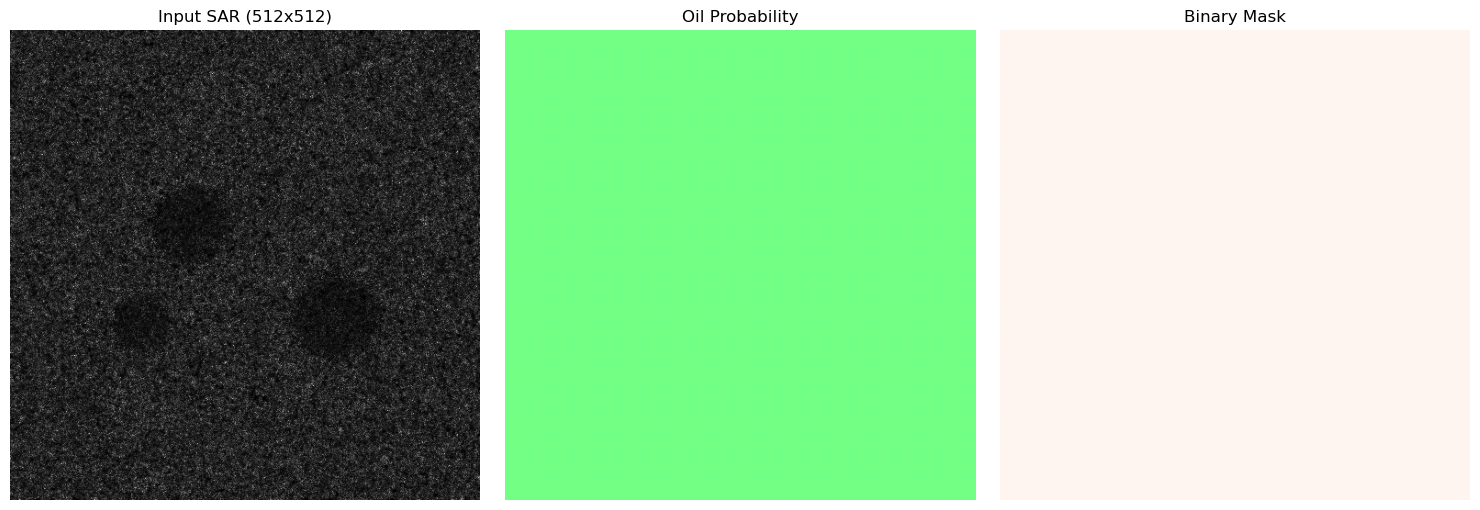


CELL 22 COMPLETE
  ... still running (520s)
  ... still running (530s)
  ... still running (540s)
  ... still running (550s)
  ... still running (560s)
  ... still running (570s)
  ... still running (580s)
  ... still running (590s)


In [4]:
# Cell 22: 512x512 with timeout protection
print("=" * 50)
print("CELL 22: Prediction (512x512 with progress)")
print("=" * 50)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import threading

# Load data
print("\nLoading data...")
data_dir = "../data/synthetic_training"
X = np.load(f"{data_dir}/X_train.npy")
Y = np.load(f"{data_dir}/Y_train.npy")

from sklearn.model_selection import train_test_split
_, X_val, _, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
test_image = X_val[0:1]
print(f"✓ Test sample: {test_image.shape}")

# Load model
print("\nLoading model...")
model_path = "../models/checkpoints/ndosms_best.h5"
model = tf.keras.models.load_model(model_path, safe_mode=False, compile=False)
print(f"✓ Model: {len(model.layers)} layers")

# Predict with progress indicator
print("\nPredicting (this may take 1-2 minutes on CPU)...")
print("Starting at:", time.strftime('%H:%M:%S'))

# Use a thread to show it's still alive
def show_progress():
    for i in range(60):
        time.sleep(10)
        print(f"  ... still running ({(i+1)*10}s)")

progress_thread = threading.Thread(target=show_progress, daemon=True)
progress_thread.start()

start = time.time()
prediction = model.predict(test_image, verbose=0)
elapsed = time.time() - start

print(f"\n✓ Done in {elapsed:.1f} seconds")
print(f"✓ Prediction shape: {prediction.shape}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(test_image[0,...,0], cmap='gray')
axes[0].set_title('Input SAR (512x512)')
axes[0].axis('off')

axes[1].imshow(prediction[0,...,1], cmap='jet', vmin=0, vmax=1)
axes[1].set_title('Oil Probability')
axes[1].axis('off')

binary = (prediction[0,...,1] > 0.5).astype(float)
axes[2].imshow(binary, cmap='Reds')
axes[2].set_title('Binary Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("CELL 22 COMPLETE")
print("=" * 50)